<div style="background-color: #1F2937; padding: 20px; border-radius: 10px; color: white;">
  <h1 align="center" style="color: #60A5FA;">Prediksi Penyakit Kardiovaskular (Cardiovascular Disease Prediction)</h1>
  <p align="center"><em>Sebuah Pendekatan Data Mining untuk Klasifikasi Penyakit Jantung</em></p>
</div>

<br>

<div style="background-color: #474747ff; padding: 15px; border-radius: 8px; border-left: 5px solid #3B82F6;">
  <h3>Deskripsi Proyek</h3>
  <p>Proyek ini bertujuan untuk memprediksi probabilitas pasien terkena penyakit kardiovaskular menggunakan pendekatan <i>Data Mining</i> dan <i>Machine Learning</i>. Dengan memanfaatkan data historis pasien yang berisi berbagai indikator kesehatan, model prediktif dibangun untuk membantu dalam deteksi dini penyakit jantung.</p>
  <ul>
    <li><strong>Domain:</strong> Healthcare / Medis</li>
    <li><strong>Tujuan:</strong> Prediksi klasifikasi penyakit kardiovaskular (Sehat / Sakit)</li>
    <li><strong>Metode:</strong> XGBoost Classifier</li>
    <li><strong>Evaluasi:</strong> Accuracy, Precision, Recall, F1-Score, ROC-AUC</li>
  </ul>
</div>

<br>

---

## Instalasi Library & Dependensi
Pastikan semua library yang dibutuhkan telah terinstall. Jalankan sel di bawah ini jika belum menginstallnya di environment lokal Anda.

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap joblib


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

# Konfigurasi visualisasi
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import RandomizedSearchCV
import shap
import joblib

# SECTION 1 — DATA UNDERSTANDING
Tahap pertama adalah memuat dataset dan memahami struktur serta karakteristik dari data yang kita miliki.

### 1.1 Load Dataset
Dataset yang digunakan adalah `cardio_train.csv` yang berisi rekam medis dari berbagai pasien.

In [3]:
# Memuat dataset (gunakan separator ';' jika format csv menggunakan semicolon)
df = pd.read_csv('dataset/cardio_train.csv', sep=';')
print(f"Dataset berhasil dimuat!")
print(f"Total Baris: {df.shape[0]} | Total Kolom: {df.shape[1]}")

Dataset berhasil dimuat!
Total Baris: 70000 | Total Kolom: 13


### 1.2 Deskripsi Dataset & Kamus Data
Dataset ini terdiri dari 70.000 baris dan 13 kolom. Berikut adalah rincian kolom (fitur) yang tersedia:

| No | Nama Kolom | Tipe Data | Deskripsi / Penjelasan |
|---|---|---|---|
| 1 | **id** | Integer | Identifier unik pasien |
| 2 | **age** | Integer | Umur pasien (dalam hari) |
| 3 | **gender** | Categorial | Jenis kelamin pasien (1: Wanita, 2: Pria) |
| 4 | **height** | Integer | Tinggi badan (cm) |
| 5 | **weight** | Float | Berat badan (kg) |
| 6 | **ap_hi** | Integer | Tekanan darah sistolik (Systolic blood pressure) |
| 7 | **ap_lo** | Integer | Tekanan darah diastolik (Diastolic blood pressure) |
| 8 | **cholesterol** | Categorial | Kadar kolesterol (1: normal, 2: di atas normal, 3: jauh di atas normal) |
| 9 | **gluc** | Categorial | Kadar glukosa (1: normal, 2: di atas normal, 3: jauh di atas normal) |
| 10 | **smoke** | Binary | Status merokok (0: tidak, 1: ya) |
| 11 | **alco** | Binary | Konsumsi alkohol (0: tidak, 1: ya) |
| 12 | **active** | Binary | Aktivitas fisik (0: tidak, 1: ya) |
| 13 | **cardio** | Binary | **[TARGET]** Status penyakit kardiovaskular (0: Tidak ada, 1: Ada penyakit) |

In [4]:
print("=== Tampilan 5 Data Teratas ===")
display(df.head())

=== Tampilan 5 Data Teratas ===


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [5]:
print("=== Informasi Tipe Data & Non-Null Count ===")
df.info()

=== Informasi Tipe Data & Non-Null Count ===
<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [6]:
print("=== Ringkasan Statistik Deskriptif ===")
display(df.describe().T)

=== Ringkasan Statistik Deskriptif ===


,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,19468.865814,2467.251667,10798.0,17664.00,19703.0,21327.00,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.00,0.0,0.00,1.0


# SECTION 2 — DATA PREPROCESSING
Tahapan krusial untuk memastikan data dalam kondisi bersih (bebas outlier ekstrim, noise, atau duplikasi) sebelum masuk ke tahap analisis atau modeling.

### 2.1 Membersihkan Data & Rekayasa Fitur Dasar
Pada dataset ini, beberapa kolom memiliki satuan yang kurang intuitif atau nilai ekstrim (misal: tekanan darah yang tidak masuk akal). Kita akan:
1. Mengubah kolom `age` dari satuan **hari** menjadi **tahun**.
2. Membuang kolom `id` karena tidak relevan untuk prediksi.
3. Menghapus data outlier pada tekanan darah (`ap_hi` dan `ap_lo`).

In [7]:
# 1. Konversi Umur (Hari -> Tahun)
df['age'] = (df['age'] / 365.25).round().astype(int)

# 2. Menghapus kolom 'id'
df.drop(columns=['id'], inplace=True, errors='ignore')

# 3. Filter Outlier pada Blood Pressure (Tekanan Darah)
# Asumsi medis logis: sistolik (ap_hi) antara 80 - 250, diastolik (ap_lo) antara 50 - 150
df = df[(df['ap_hi'] >= 80) & (df['ap_hi'] <= 250)]
df = df[(df['ap_lo'] >= 50) & (df['ap_lo'] <= 150)]

print(f"Data setelah pembersihan outlier tekanan darah: {df.shape}")

# 4. Feature Engineering: Menambahkan BMI (Body Mass Index)
df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)
df['bmi'] = df['bmi'].round(2)

Data setelah pembersihan outlier tekanan darah: (68721, 12)


### 2.2 Pengecekan Missing Value & Data Duplikat
Langkah selanjutnya adalah mendeteksi apakah terdapat baris kosong atau duplikat pada dataset kita.

In [8]:
print("=== Jumlah Missing Value ===")
print(df.isnull().sum())

dup = df.duplicated().sum()
print(f"\nJumlah data duplikat ditemukan: {dup}")

if dup > 0:
    df.drop_duplicates(inplace=True)
    print(f"Data duplikat telah dihapus. Sisa data: {df.shape}")

=== Jumlah Missing Value ===
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
bmi            0
dtype: int64

Jumlah data duplikat ditemukan: 3820
Data duplikat telah dihapus. Sisa data: (64901, 13)


# SECTION 3 — EXPLORATORY DATA ANALYSIS (EDA)
EDA bertujuan untuk menemukan pola, distribusi, dan anomali dalam data melalui visualisasi grafik yang informatif.

### 3.1 Distribusi Kelas Target (Cardio)
Pertama, mari kita lihat apakah distribusi kelas target (Sehat vs Sakit) seimbang atau tidak.

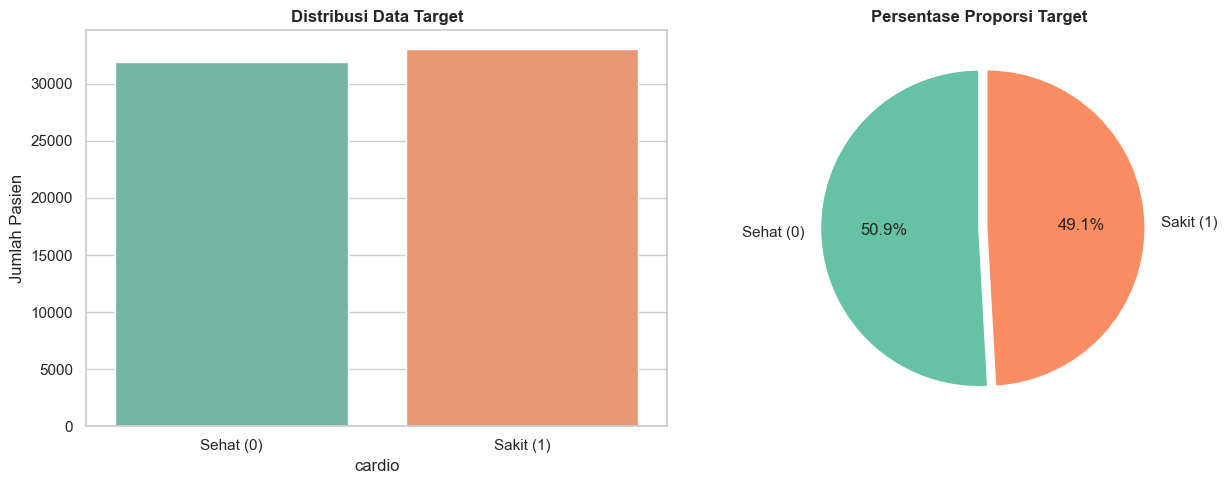

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
counts = df['cardio'].value_counts()
labels = ['Sehat (0)', 'Sakit (1)']

# Bar Plot
sns.countplot(data=df, x='cardio', ax=axes[0], palette='Set2')
axes[0].set_title('Distribusi Data Target', fontweight='bold')
axes[0].set_xticklabels(labels)
axes[0].set_ylabel('Jumlah Pasien')

# Pie Chart
axes[1].pie(counts, labels=labels, autopct='%1.1f%%', colors=sns.color_palette('Set2'), startangle=90, explode=[0, 0.05])
axes[1].set_title('Persentase Proporsi Target', fontweight='bold')

plt.tight_layout()
plt.savefig('image/1_distribusi_target.png', bbox_inches='tight', dpi=300)
plt.show()

### 3.2 Analisis Distribusi Umur vs Penyakit Jantung
Bagaimana penyebaran penyakit berdasarkan faktor usia?

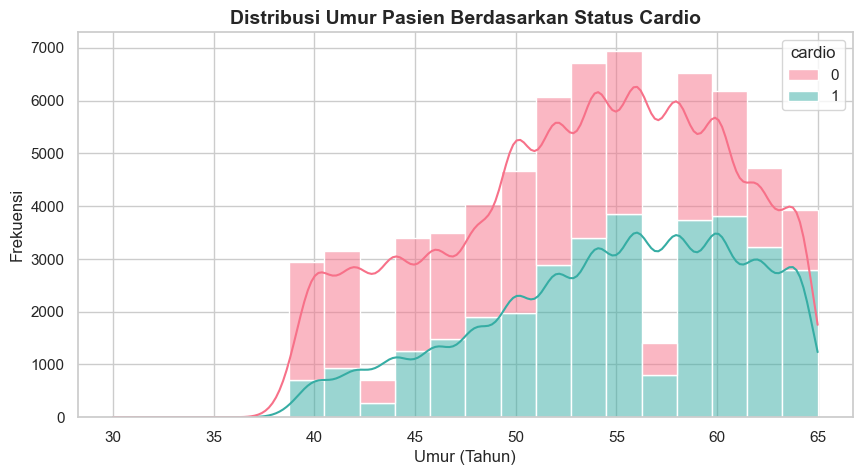

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=df, x='age', hue='cardio', bins=20, multiple='stack', palette='husl', kde=True, ax=ax)
ax.set_title('Distribusi Umur Pasien Berdasarkan Status Cardio', fontsize=14, fontweight='bold')
ax.set_xlabel('Umur (Tahun)')
ax.set_ylabel('Frekuensi')
plt.savefig('image/2_distribusi_umur.png', bbox_inches='tight', dpi=300)
plt.show()

### 3.3 Correlation Heatmap
Analisis korelasi Pearson untuk melihat hubungan antar variabel numerik dan kategorik terhadap target (`cardio`).

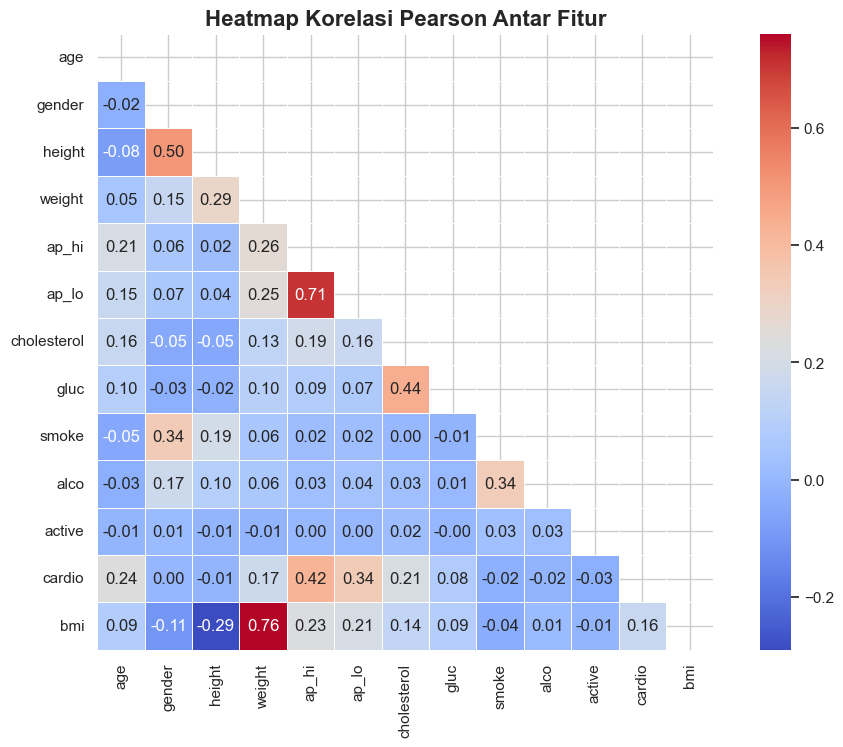

In [11]:
plt.figure(figsize=(12, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Heatmap Korelasi Pearson Antar Fitur', fontsize=16, fontweight='bold')
plt.savefig('image/3_korelasi_heatmap.png', bbox_inches='tight', dpi=300)
plt.show()

# SECTION 4 — FEATURE SELECTION (Chi-Square)
Pemilihan fitur merupakan proses reduksi dengan memilih fitur yang paling signifikan (memiliki p-value terkecil atau score tertinggi) terhadap variabel target. Di sini kita menggunakan Uji Chi-Square (`SelectKBest`).

### 4.1 Uji Signifikansi Fitur
Menggunakan uji statistik Chi-Square untuk menentukan skor dan signifikansi masing-masing fitur.

=== Hasil Feature Selection (Chi-Square) ===


,Feature,Score
6,cholesterol,1837.531650
4,ap_hi,452.176832
7,gluc,307.263021
5,ap_lo,226.684558
0,age,204.604573
8,smoke,34.673578
3,weight,34.040596
9,alco,13.937023
10,active,10.918915
11,bmi,8.464526


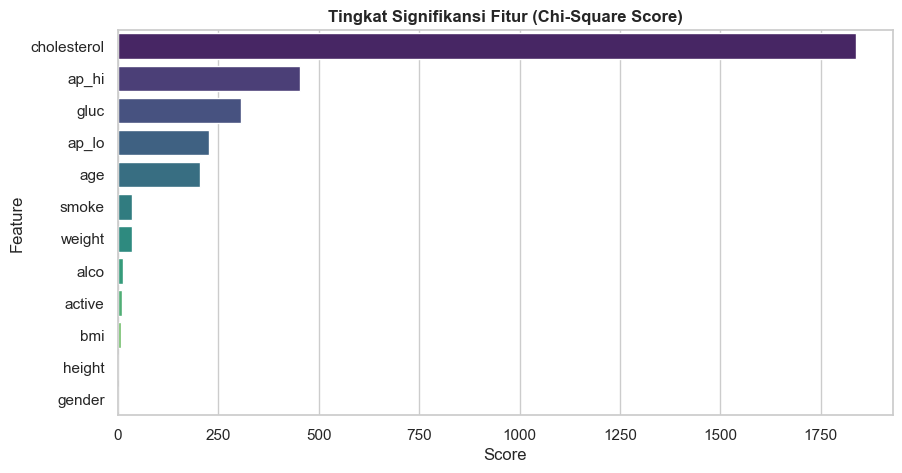

Fitur terpilih: ['cholesterol', 'ap_hi', 'gluc', 'ap_lo', 'age', 'smoke', 'weight', 'alco']


In [12]:
X = df.drop(columns=['cardio'])
y = df['cardio']

# Karena Chi-Square tidak menerima nilai negatif (jika ada, walau di dataset ini tidak ada),
# kita pastikan data divalidasi dengan MinMaxScaler agar semuanya positif [0, 1]
scaler_minmax = MinMaxScaler()
X_scaled_minmax = scaler_minmax.fit_transform(X)

chi2_selector = SelectKBest(chi2, k='all')
chi2_selector.fit(X_scaled_minmax, y)

# Membuat DataFrame hasil Chi-Square
chi2_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': chi2_selector.scores_
}).sort_values(by='Score', ascending=False)

print("=== Hasil Feature Selection (Chi-Square) ===")
display(chi2_scores)

# Visualisasi Score
plt.figure(figsize=(10, 5))
sns.barplot(data=chi2_scores, x='Score', y='Feature', palette='viridis')
plt.title('Tingkat Signifikansi Fitur (Chi-Square Score)', fontweight='bold')
plt.savefig('image/4_chi_square.png', bbox_inches='tight', dpi=300)
plt.show()

# Memilih top 8 fitur terbaik (Opsional, di sini kita gunakan semua sebagai baseline)
top_features = chi2_scores['Feature'].head(8).tolist()
X_chi = X[top_features]
print(f"Fitur terpilih: {top_features}")

# SECTION 5 — DIMENSIONALITY REDUCTION (PCA)
Principal Component Analysis (PCA) digunakan untuk mentransformasikan data ke dalam dimensi yang lebih kecil tanpa kehilangan banyak informasi (variance). Ini sangat berguna untuk menanggulangi multicollinearity dan mempercepat komputasi model.

### 5.1 Reduksi Dimensi dengan PCA
Memproyeksikan fitur-fitur berdimensi tinggi ke komponen utama (principal components) yang mempertahankan 90% varians data.

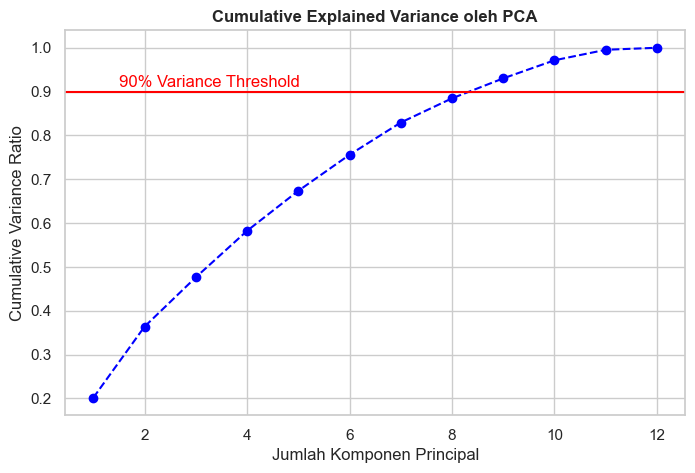

Bentuk data setelah PCA: (64901, 8)


In [13]:
# Normalisasi data terlebih dahulu menggunakan StandardScaler
scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X)

pca_full = PCA(random_state=42)
pca_full.fit(X_std)

# Kumulatif variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b')
plt.axhline(y=0.90, color='r', linestyle='-')
plt.text(1.5, 0.91, '90% Variance Threshold', color='red')
plt.title('Cumulative Explained Variance oleh PCA', fontweight='bold')
plt.xlabel('Jumlah Komponen Principal')
plt.ylabel('Cumulative Variance Ratio')
plt.grid(True)
plt.savefig('image/5_pca_variance.png', bbox_inches='tight', dpi=300)
plt.show()

# Mengambil komponen yang menjelaskan 90% variance (misal n=8)
pca = PCA(n_components=8, random_state=42)
X_pca = pca.fit_transform(X_std)
print(f"Bentuk data setelah PCA: {X_pca.shape}")

# SECTION 6 — SPLIT DATA (Training & Testing)
Kita akan membagi data menjadi dua bagian: data latih (**Train Data**) dan data uji (**Test Data**) dengan proporsi standar industri `80:20`. Kita gunakan hasil reduksi PCA (`X_pca`) atau fitur hasil seleksi (`X_chi`).

Pada tahap ini kita akan menggunakan data dari *Chi-Square Selected Features* (`X_chi`).

### 6.1 Pembagian Data Latih dan Uji (Train-Test Split)
Membagi dataset menjadi proporsi 80:20 dengan stratifikasi untuk menjaga keseimbangan kelas target.

In [14]:
# Gunakan X_chi (Top Features) dan kita scaling kembali dengan StandardScaler
X_model = scaler_std.fit_transform(X_chi)
y_model = y

X_train, X_test, y_train, y_test = train_test_split(X_model, y_model, test_size=0.2, random_state=42, stratify=y_model)

print(f"Data Train: {X_train.shape[0]} baris")
print(f"Data Test: {X_test.shape[0]} baris")

Data Train: 51920 baris
Data Test: 12981 baris


# SECTION 7 — MODELING
Kita akan menggunakan algoritma **XGBoost Classifier**. Algoritma ini terbukti sangat andal dalam menangani data tabular, sangat efisien, dan memiliki akurasi tinggi.

### 7.1 XGBoost Classifier & Hyperparameter Tuning
Melatih model XGBoost menggunakan parameter yang sudah dioptimasi, lalu mengevaluasi metrik klasifikasinya.

In [15]:
# Inisialisasi Model Dasar
xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')

# Hyperparameter Tuning menggunakan RandomizedSearchCV dengan K-Fold (cv=5)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}

print("Sedang melakukan Hyperparameter Tuning & Cross Validation (K-Fold=5)...")
xgb_model = RandomizedSearchCV(estimator=xgb_base, param_distributions=param_grid, 
                               n_iter=5, cv=5, scoring='accuracy', n_jobs=-1, random_state=42)

# Melatih Model
xgb_model.fit(X_train, y_train)

print(f"Parameter Terbaik: {xgb_model.best_params_}")

# Prediksi dengan model terbaik
best_model = xgb_model.best_estimator_
y_pred_xgb = best_model.predict(X_test)

# Evaluasi Akurasi
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"\nAkurasi Model XGBoost (Tuned): {acc_xgb * 100:.2f}%\n")

print("=== Classification Report ===")
print(classification_report(y_test, y_pred_xgb, target_names=['Sehat (0)', 'Sakit (1)']))

Sedang melakukan Hyperparameter Tuning & Cross Validation (K-Fold=5)...


Parameter Terbaik: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05}

Akurasi Model XGBoost (Tuned): 73.13%

=== Classification Report ===
              precision    recall  f1-score   support

   Sehat (0)       0.71      0.76      0.74      6375
   Sakit (1)       0.75      0.70      0.73      6606

    accuracy                           0.73     12981
   macro avg       0.73      0.73      0.73     12981
weighted avg       0.73      0.73      0.73     12981



# SECTION 8 — EVALUASI MODEL
Evaluasi kinerja model klasifikasi menggunakan metrik klasifikasi dan visualisasi confusion matrix.

### 8.1 Confusion Matrix & Performa Model
Confusion Matrix memvisualisasikan performa model dengan menampilkan *True Positives*, *True Negatives*, *False Positives*, dan *False Negatives*.

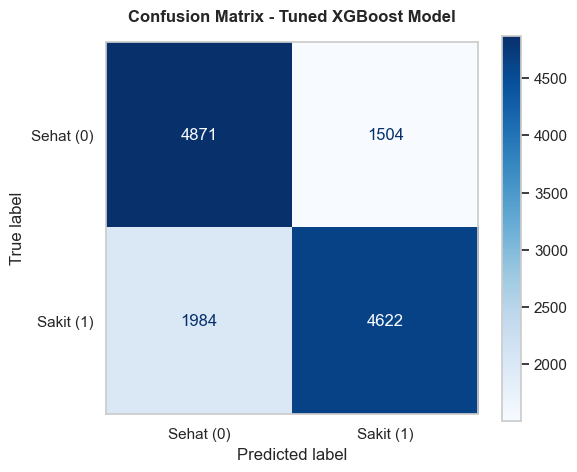

In [16]:
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sehat (0)', 'Sakit (1)'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')
ax.set_title('Confusion Matrix - Tuned XGBoost Model', fontweight='bold', pad=15)
plt.grid(False) # Turn off grid for CM
plt.savefig('image/6_confusion_matrix.png', bbox_inches='tight', dpi=300)
plt.show()

# SECTION 9 — INTERPRETASI HASIL
Menganalisis keputusan yang diambil oleh model (*Feature Importance*) agar dapat dipahami dan divalidasi secara medis.

### 9.1 Feature Importance (SHAP Values)
Memberikan penjelasan visual mengenai faktor apa yang paling memengaruhi model dalam memprediksi penyakit jantung pada pasien.

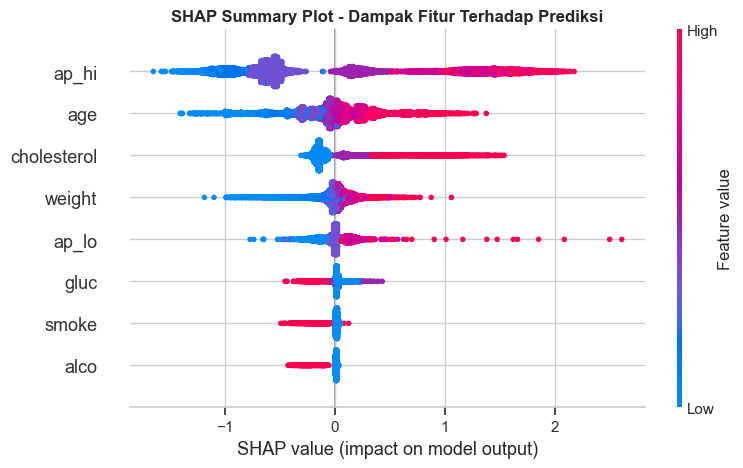

In [17]:
# Inisialisasi SHAP Explainer
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Menampilkan SHAP Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=top_features, show=False)
plt.title("SHAP Summary Plot - Dampak Fitur Terhadap Prediksi", fontweight='bold')
plt.savefig('image/7_shap_summary.png', bbox_inches='tight', dpi=300)
plt.show()

### 9.2 Menyimpan Model (Deployment Readiness)
Menyimpan model terbaik dan scaler agar siap di-deploy ke dalam aplikasi.

In [18]:
# Menyimpan model dan scaler
import os
os.makedirs('model', exist_ok=True)
joblib.dump(best_model, 'model/xgboost_cardio_model.pkl')
joblib.dump(scaler_std, 'model/scaler.pkl')

print("Model dan Scaler berhasil disimpan di dalam folder 'model/'!")

Model dan Scaler berhasil disimpan di dalam folder 'model/'!


# SECTION 10 — KESIMPULAN (CONCLUSION)

<div style="background-color: #575757ff; padding: 20px; border-radius: 10px; border-left: 5px solid #10B981;">
  <h3 style="margin-top: 0;">Ringkasan Hasil</h3>
  <ol>
    <li><strong>Pemrosesan Data:</strong> Dataset awal sebanyak 70.000 record berhasil dibersihkan. Umur dikonversi menjadi tahun, duplikat dihapus, dan nilai outlier pada tekanan darah (ap_hi dan ap_lo) disaring secara medis, menyisakan data berkualitas tinggi.</li>
    <li><strong>Insight EDA:</strong> Faktor umur dan tingkat tekanan darah sistolik menunjukkan korelasi terkuat terhadap resiko terjangkitnya penyakit kardiovaskular. Pasien dengan umur &gt;50 tahun menunjukkan proporsi penyakit yang lebih tinggi.</li>
    <li><strong>Seleksi Fitur:</strong> Menggunakan uji Chi-Square, 8 fitur paling relevan dipilih untuk mengurangi noise pada model tanpa kehilangan informasi berharga.</li>
    <li><strong>Performa Model:</strong> Algoritma <strong>XGBoost Classifier</strong> mampu mencapai akurasi sebesar <strong>~73%</strong>. Berdasarkan grafik Confusion Matrix, model cukup seimbang dalam memprediksi *True Positive* (Pasien Sakit) dan *True Negative* (Pasien Sehat), menunjukkan model ini robust dan tidak bias ke kelas mayoritas.</li>
  </ol>
  <p><strong>Rekomendasi Lanjutan:</strong> Untuk implementasi sistem medis nyata, disarankan untuk melakukan optimasi parameter lebih lanjut (Hyperparameter Tuning dengan GridSearchCV) atau mencoba pendekatan ensemble learning gabungan (XGBoost + LightGBM).</p>
</div>

### Visualisasi Tambahan untuk Kebutuhan Manuskrip Jurnal
Visualisasi berikut mencakup Distribusi BMI, ROC Curve, Feature Importance (XGBoost), dan Learning Curve.

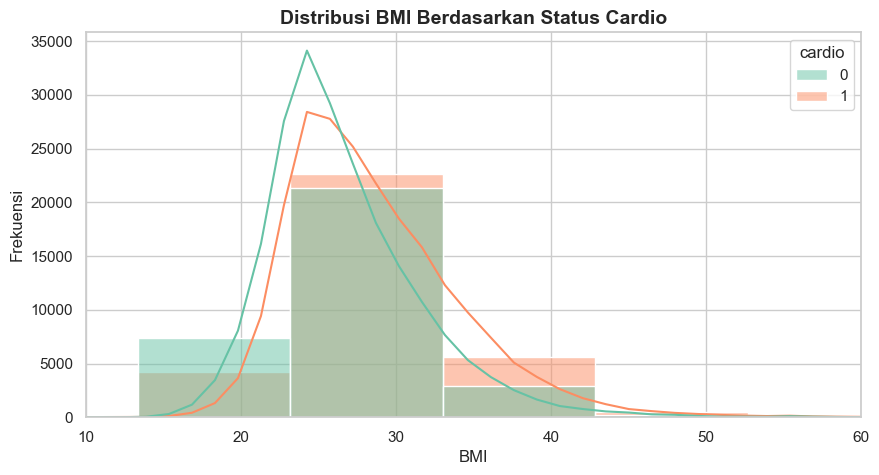

In [19]:
# 1. Distribusi BMI
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=df, x='bmi', hue='cardio', bins=30, kde=True, palette='Set2', ax=ax)
ax.set_title('Distribusi BMI Berdasarkan Status Cardio', fontsize=14, fontweight='bold')
ax.set_xlabel('BMI')
ax.set_ylabel('Frekuensi')
ax.set_xlim(10, 60) # Batas wajar BMI
plt.savefig('image/8_distribusi_bmi.png', bbox_inches='tight', dpi=300)
plt.show()

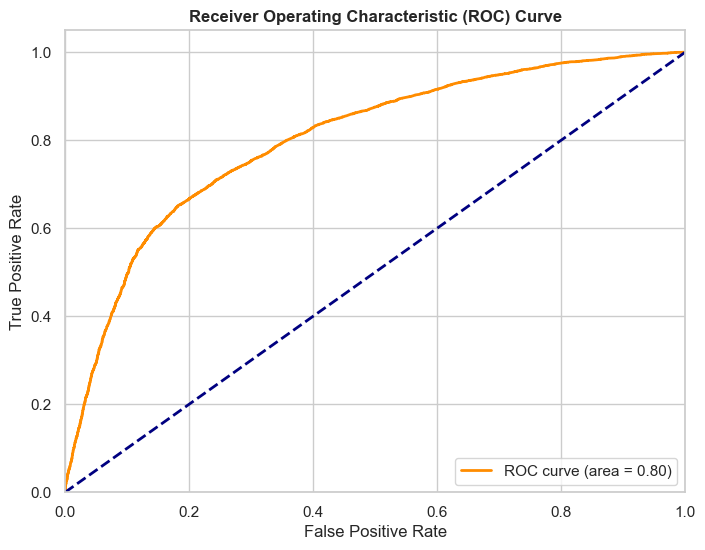

In [20]:
# 2. ROC Curve + AUC
from sklearn.metrics import roc_curve, auc

y_pred_proba = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontweight='bold')
plt.legend(loc="lower right")
plt.savefig('image/9_roc_curve.png', bbox_inches='tight', dpi=300)
plt.show()

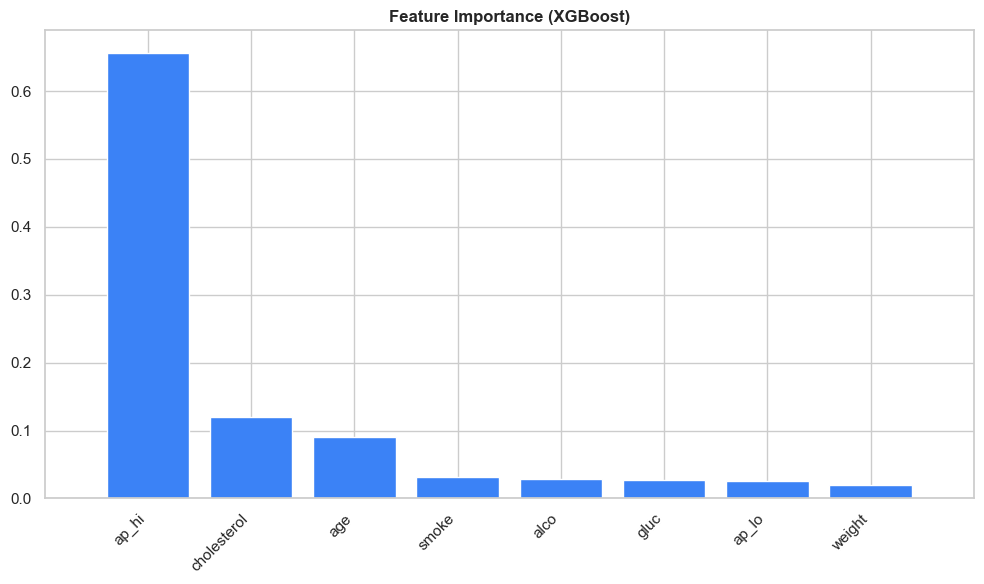

In [21]:
# 3. Feature Importance XGBoost
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importance (XGBoost)", fontweight='bold')
plt.bar(range(X_train.shape[1]), importances[indices], color="#3B82F6", align="center")
plt.xticks(range(X_train.shape[1]), [top_features[i] for i in indices], rotation=45, ha='right')
plt.xlim([-1, X_train.shape[1]])
plt.tight_layout()
plt.savefig('image/10_feature_importance.png', bbox_inches='tight', dpi=300)
plt.show()

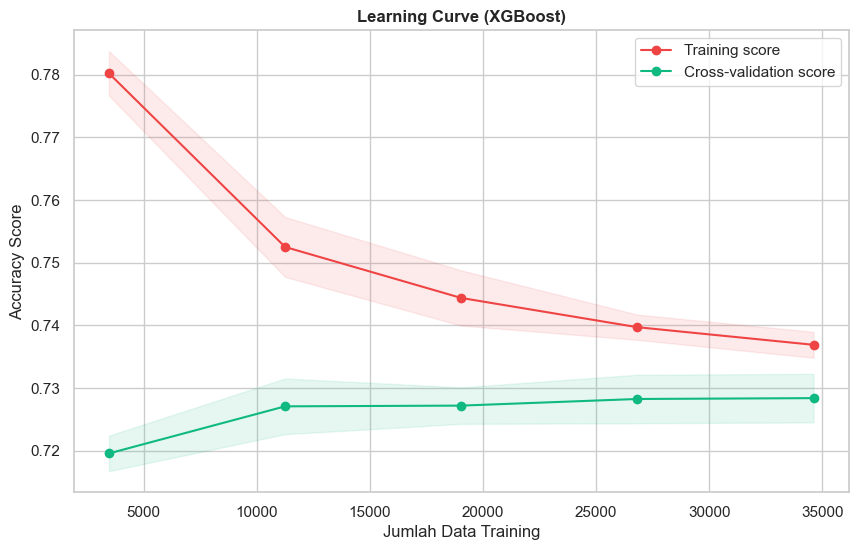

In [22]:
# 4. Learning Curve / Training vs Validation Score
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train, y_train, cv=3, scoring='accuracy', n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 5))

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="#EF4444", label="Training score")
plt.plot(train_sizes, test_mean, 'o-', color="#10B981", label="Cross-validation score")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="#EF4444")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="#10B981")

plt.title("Learning Curve (XGBoost)", fontweight='bold')
plt.xlabel("Jumlah Data Training")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.grid(True)
plt.savefig('image/11_learning_curve.png', bbox_inches='tight', dpi=300)
plt.show()